In [11]:
import pandas as pd

In [12]:
results_df = pd.read_csv('retrieval_experiment_results_OLD.csv')
results_df.head(40)

,bi_encoder,reranker,MRR@15,HitRate@3,HitRate@5,HitRate@10,avg_time_retrieval_sec,avg_time_rerank_sec,total_time_retrieval_sec,total_time_rerank_sec
0,sentence-transformers/all-MiniLM-L6-v2,No_Reranker,0.743475,0.799230,0.825920,0.848626,0.000406,0.000000,3.054275,0.000000
1,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-ranknet-passed_cross_...,0.841157,0.852609,0.856991,0.859381,0.000439,0.017540,3.306334,132.094202
2,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-ranknet-passed_oracle...,0.717854,0.772009,0.810517,0.848758,0.000414,0.017526,3.114211,131.989615
3,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-triplet-passed_cross_...,0.835920,0.853804,0.857788,0.858850,0.000397,0.017591,2.991217,132.480682
4,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-triplet-passed_oracle...,0.836758,0.852211,0.856593,0.858983,0.000400,0.017562,3.009335,132.257382
5,sentence-transformers/all-MiniLM-L6-v2,ms-marco-MiniLM-L6-v2,0.770922,0.797238,0.807861,0.818616,0.000402,0.017541,3.023845,132.098586
6,sentence-transformers/all-mpnet-base-v2,No_Reranker,0.747496,0.795114,0.819944,0.841986,0.000814,0.000000,6.131062,0.000000
7,sentence-transformers/all-mpnet-base-v2,msmarco-minilm-finetuned-ranknet-passed_cross_...,0.832591,0.844244,0.848626,0.851149,0.000813,0.020631,6.119576,155.374004
8,sentence-transformers/all-mpnet-base-v2,msmarco-minilm-finetuned-ranknet-passed_oracle...,0.705033,0.756872,0.796441,0.840260,0.000871,0.020627,6.560599,155.338924
9,sentence-transformers/all-mpnet-base-v2,msmarco-minilm-finetuned-triplet-passed_cross_...,0.827507,0.846103,0.849555,0.851149,0.000820,0.020674,6.172472,155.696650


In [22]:
results_df['reranker'].unique()

<ArrowStringArray>
[                                                             'No_Reranker',
 'msmarco-minilm-finetuned-ranknet-passed_cross_mining_method_validated_df',
        'msmarco-minilm-finetuned-ranknet-passed_oracle_method_vlidated_df',
 'msmarco-minilm-finetuned-triplet-passed_cross_mining_method_validated_df',
        'msmarco-minilm-finetuned-triplet-passed_oracle_method_vlidated_df',
                                                    'ms-marco-MiniLM-L6-v2']
Length: 6, dtype: str

In [24]:
results_df.replace(
    {
        'msmarco-minilm-finetuned-ranknet-passed_cross_mining_method_validated_df': 'RankNet+CrossMining',
        'msmarco-minilm-finetuned-ranknet-passed_oracle_method_vlidated_df': 'RankNet+SimilarityMining',
        'msmarco-minilm-finetuned-triplet-passed_cross_mining_method_validated_df': 'CustomTriplet+CrossMining',
        'msmarco-minilm-finetuned-triplet-passed_oracle_method_vlidated_df': 'CustomTriplet+SimilarityMining',
        'ms-marco-MiniLM-L6-v2': 'MiniLM (baseline)'
    },
    inplace=True
)

,bi_encoder,reranker,MRR@15,HitRate@3,HitRate@5,HitRate@10,avg_time_retrieval_sec,avg_time_rerank_sec,total_time_retrieval_sec,total_time_rerank_sec
0,sentence-transformers/all-MiniLM-L6-v2,No_Reranker,0.743475,0.799230,0.825920,0.848626,0.000406,0.000000,3.054275,0.000000
1,sentence-transformers/all-MiniLM-L6-v2,RankNet+CrossMining,0.841157,0.852609,0.856991,0.859381,0.000439,0.017540,3.306334,132.094202
2,sentence-transformers/all-MiniLM-L6-v2,RankNet+SimilarityMining,0.717854,0.772009,0.810517,0.848758,0.000414,0.017526,3.114211,131.989615
3,sentence-transformers/all-MiniLM-L6-v2,CustomTriplet+CrossMining,0.835920,0.853804,0.857788,0.858850,0.000397,0.017591,2.991217,132.480682
4,sentence-transformers/all-MiniLM-L6-v2,CustomTriplet+SimilarityMining,0.836758,0.852211,0.856593,0.858983,0.000400,0.017562,3.009335,132.257382
5,sentence-transformers/all-MiniLM-L6-v2,MiniLM (baseline),0.770922,0.797238,0.807861,0.818616,0.000402,0.017541,3.023845,132.098586
6,sentence-transformers/all-mpnet-base-v2,No_Reranker,0.747496,0.795114,0.819944,0.841986,0.000814,0.000000,6.131062,0.000000
7,sentence-transformers/all-mpnet-base-v2,RankNet+CrossMining,0.832591,0.844244,0.848626,0.851149,0.000813,0.020631,6.119576,155.374004
8,sentence-transformers/all-mpnet-base-v2,RankNet+SimilarityMining,0.705033,0.756872,0.796441,0.840260,0.000871,0.020627,6.560599,155.338924
9,sentence-transformers/all-mpnet-base-v2,CustomTriplet+CrossMining,0.827507,0.846103,0.849555,0.851149,0.000820,0.020674,6.172472,155.696650


In [25]:
results_df.describe()

,MRR@15,HitRate@3,HitRate@5,HitRate@10,avg_time_retrieval_sec,avg_time_rerank_sec,total_time_retrieval_sec,total_time_rerank_sec
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,0.771366,0.799665,0.813021,0.825543,0.000936,0.016710,7.050927,125.839749
std,0.054146,0.042124,0.034107,0.029186,0.000552,0.007697,4.158819,57.964910
min,0.649032,0.712522,0.740274,0.764308,0.000397,0.000000,2.991217,0.000000
25%,0.743301,0.771843,0.801620,0.814566,0.000546,0.017556,4.110227,132.217683
50%,0.770206,0.798566,0.815762,0.827048,0.000819,0.019655,6.164773,148.023950
75%,0.815193,0.829704,0.837140,0.849754,0.000908,0.021500,6.841785,161.916221
max,0.841477,0.853804,0.857788,0.859381,0.002143,0.021807,16.137975,164.225589


In [26]:
results_df.columns

Index(['bi_encoder', 'reranker', 'MRR@15', 'HitRate@3', 'HitRate@5',
       'HitRate@10', 'avg_time_retrieval_sec', 'avg_time_rerank_sec',
       'total_time_retrieval_sec', 'total_time_rerank_sec'],
      dtype='str')

In [27]:
NEW_results_df = pd.read_csv('retrieval_experiment_results.csv')
NEW_results_df.head(40)

,bi_encoder,reranker,MRR@15,HitRate@3,HitRate@5,HitRate@10,avg_time_retrieval_sec,avg_time_rerank_sec,total_time_retrieval_sec,total_time_rerank_sec
0,sentence-transformers/all-MiniLM-L6-v2,No_Reranker,0.811624,0.854904,0.875632,0.895349,0.000353,0.000000,0.698135,0.000000
1,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-ranknet-passed_cross_...,0.889208,0.899393,0.901921,0.903943,0.000374,0.015918,0.739936,31.486176
2,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-ranknet-passed_oracle...,0.739494,0.796764,0.845804,0.889788,0.000366,0.015953,0.724662,31.555897
3,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-triplet-passed_cross_...,0.891173,0.900910,0.902932,0.902932,0.000355,0.015940,0.702899,31.528983
4,sentence-transformers/all-MiniLM-L6-v2,msmarco-minilm-finetuned-triplet-passed_oracle...,0.887834,0.899899,0.902932,0.903943,0.000349,0.015928,0.690047,31.505733
5,sentence-transformers/all-MiniLM-L6-v2,ms-marco-MiniLM-L6-v2,0.770351,0.780586,0.793225,0.818504,0.000351,0.015965,0.694330,31.578839
6,sentence-transformers/all-mpnet-base-v2,No_Reranker,0.797429,0.835693,0.859454,0.884732,0.000684,0.000000,1.353803,0.000000
7,sentence-transformers/all-mpnet-base-v2,msmarco-minilm-finetuned-ranknet-passed_cross_...,0.883030,0.894338,0.897371,0.899393,0.000696,0.018031,1.377355,35.666253
8,sentence-transformers/all-mpnet-base-v2,msmarco-minilm-finetuned-ranknet-passed_oracle...,0.724448,0.787664,0.834681,0.883721,0.000695,0.018000,1.374816,35.603065
9,sentence-transformers/all-mpnet-base-v2,msmarco-minilm-finetuned-triplet-passed_cross_...,0.885204,0.896360,0.898888,0.898888,0.000692,0.017979,1.368148,35.561703


In [29]:
NEW_results_df.describe()

,MRR@15,HitRate@3,HitRate@5,HitRate@10,avg_time_retrieval_sec,avg_time_rerank_sec,total_time_retrieval_sec,total_time_rerank_sec
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,0.801809,0.822703,0.835763,0.850621,0.000824,0.016112,1.630603,31.869630
std,0.069150,0.062667,0.057343,0.053254,0.000530,0.007532,1.047675,14.898727
min,0.668475,0.699191,0.730536,0.758847,0.000349,0.000000,0.690047,0.000000
25%,0.760118,0.772371,0.784884,0.814459,0.000490,0.015950,0.969522,31.549169
50%,0.785563,0.832659,0.838726,0.856673,0.000691,0.019276,1.367461,38.127056
75%,0.859919,0.872725,0.890167,0.899520,0.000773,0.020868,1.529691,41.276133
max,0.909429,0.919616,0.921638,0.921638,0.002384,0.022067,4.715486,43.648098


In [30]:
NEW_results_df.replace(
    {
        'msmarco-minilm-finetuned-ranknet-passed_cross_mining_method_validated_df': 'RankNet+CrossMining',
        'msmarco-minilm-finetuned-ranknet-passed_oracle_method_vlidated_df': 'RankNet+SimilarityMining',
        'msmarco-minilm-finetuned-triplet-passed_cross_mining_method_validated_df': 'CustomTriplet+CrossMining',
        'msmarco-minilm-finetuned-triplet-passed_oracle_method_vlidated_df': 'CustomTriplet+SimilarityMining',
        'ms-marco-MiniLM-L6-v2': 'MiniLM (baseline)'
    },
    inplace=True
)

,bi_encoder,reranker,MRR@15,HitRate@3,HitRate@5,HitRate@10,avg_time_retrieval_sec,avg_time_rerank_sec,total_time_retrieval_sec,total_time_rerank_sec
0,sentence-transformers/all-MiniLM-L6-v2,No_Reranker,0.811624,0.854904,0.875632,0.895349,0.000353,0.000000,0.698135,0.000000
1,sentence-transformers/all-MiniLM-L6-v2,RankNet+CrossMining,0.889208,0.899393,0.901921,0.903943,0.000374,0.015918,0.739936,31.486176
2,sentence-transformers/all-MiniLM-L6-v2,RankNet+SimilarityMining,0.739494,0.796764,0.845804,0.889788,0.000366,0.015953,0.724662,31.555897
3,sentence-transformers/all-MiniLM-L6-v2,CustomTriplet+CrossMining,0.891173,0.900910,0.902932,0.902932,0.000355,0.015940,0.702899,31.528983
4,sentence-transformers/all-MiniLM-L6-v2,CustomTriplet+SimilarityMining,0.887834,0.899899,0.902932,0.903943,0.000349,0.015928,0.690047,31.505733
5,sentence-transformers/all-MiniLM-L6-v2,MiniLM (baseline),0.770351,0.780586,0.793225,0.818504,0.000351,0.015965,0.694330,31.578839
6,sentence-transformers/all-mpnet-base-v2,No_Reranker,0.797429,0.835693,0.859454,0.884732,0.000684,0.000000,1.353803,0.000000
7,sentence-transformers/all-mpnet-base-v2,RankNet+CrossMining,0.883030,0.894338,0.897371,0.899393,0.000696,0.018031,1.377355,35.666253
8,sentence-transformers/all-mpnet-base-v2,RankNet+SimilarityMining,0.724448,0.787664,0.834681,0.883721,0.000695,0.018000,1.374816,35.603065
9,sentence-transformers/all-mpnet-base-v2,CustomTriplet+CrossMining,0.885204,0.896360,0.898888,0.898888,0.000692,0.017979,1.368148,35.561703


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
sns.set_theme(style="whitegrid")

In [39]:
# df = results_df.copy()
df = NEW_results_df.copy()

In [40]:
# =====================================================
# PREPROCESSING
# =====================================================

df["config"] = (
    df["bi_encoder"].astype(str)
    + "\n+\n"
    + df["reranker"].astype(str)
)

df["total_latency"] = (
    df["avg_time_retrieval_sec"]
    + df["avg_time_rerank_sec"]
)

df["has_reranker"] = df["reranker"] != "No_Reranker"

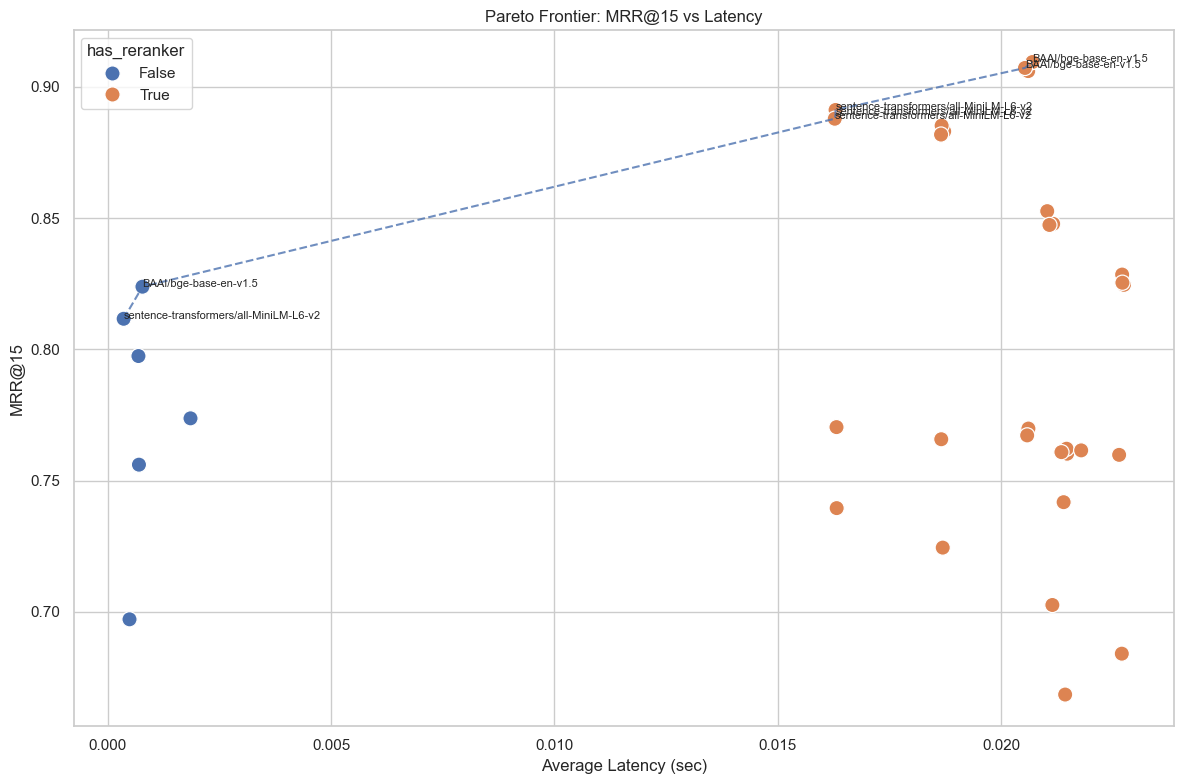

In [41]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x="total_latency",
    y="MRR@15",
    hue="has_reranker",
    s=120
)

# поиск Pareto-optimal точек
pareto_idx = []

for i, row in df.iterrows():
    dominated = (
        (df["MRR@15"] >= row["MRR@15"])
        & (df["total_latency"] <= row["total_latency"])
        & (
            (df["MRR@15"] > row["MRR@15"])
            | (df["total_latency"] < row["total_latency"])
        )
    )

    if not dominated.any():
        pareto_idx.append(i)

pareto = df.loc[pareto_idx].sort_values("total_latency")

plt.plot(
    pareto["total_latency"],
    pareto["MRR@15"],
    linestyle="--",
    alpha=0.8
)

for _, row in pareto.iterrows():
    plt.annotate(
        row["bi_encoder"],
        (row["total_latency"], row["MRR@15"]),
        fontsize=8
    )

plt.title("Pareto Frontier: MRR@15 vs Latency")
plt.xlabel("Average Latency (sec)")
plt.ylabel("MRR@15")
plt.tight_layout()

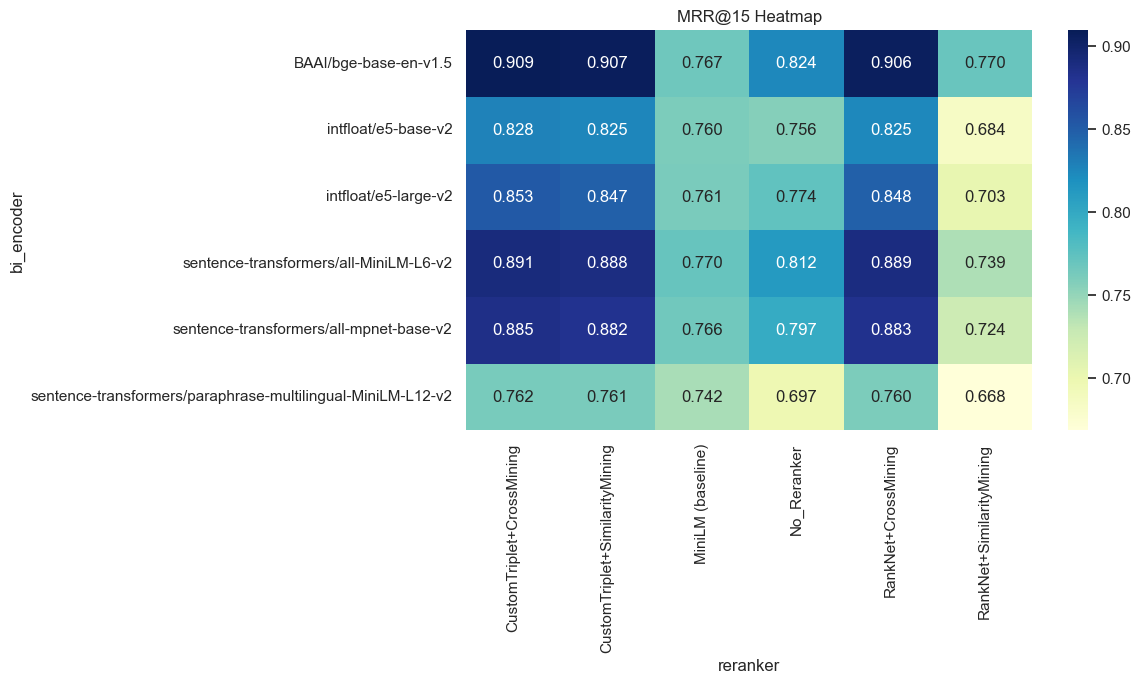

In [42]:
pivot_mrr = df.pivot_table(
    index="bi_encoder",
    columns="reranker",
    values="MRR@15"
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot_mrr,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)

plt.title("MRR@15 Heatmap")
plt.tight_layout()

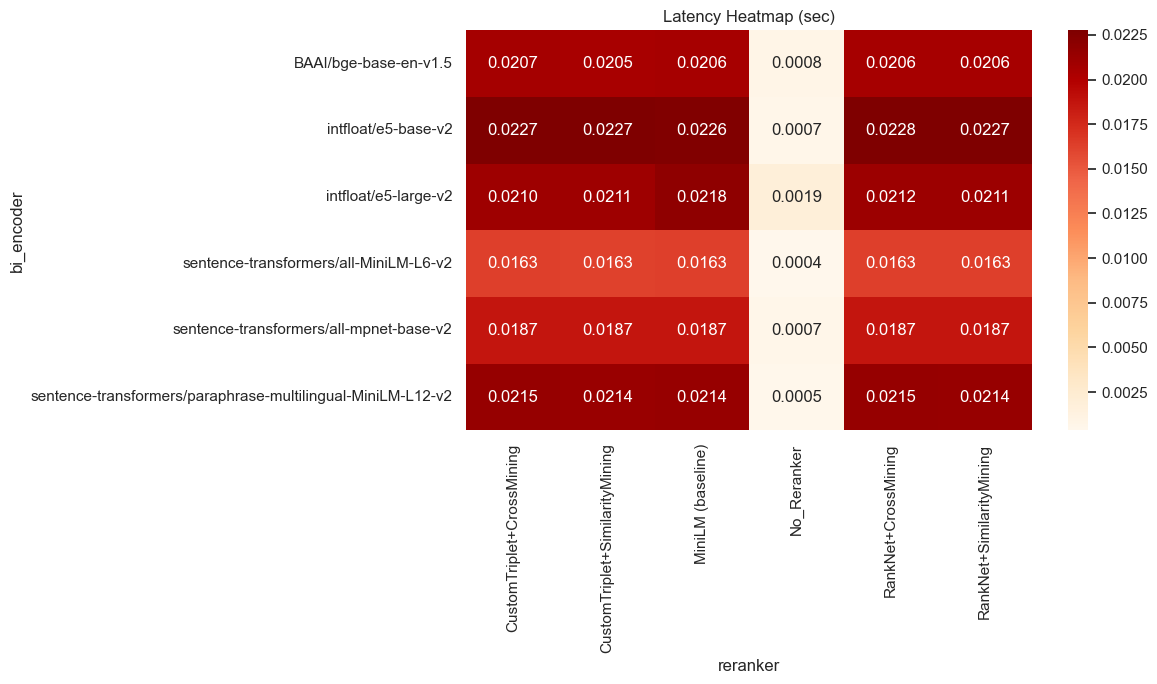

In [43]:
pivot_latency = df.pivot_table(
    index="bi_encoder",
    columns="reranker",
    values="total_latency"
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot_latency,
    annot=True,
    fmt=".4f",
    cmap="OrRd"
)

plt.title("Latency Heatmap (sec)")
plt.tight_layout()

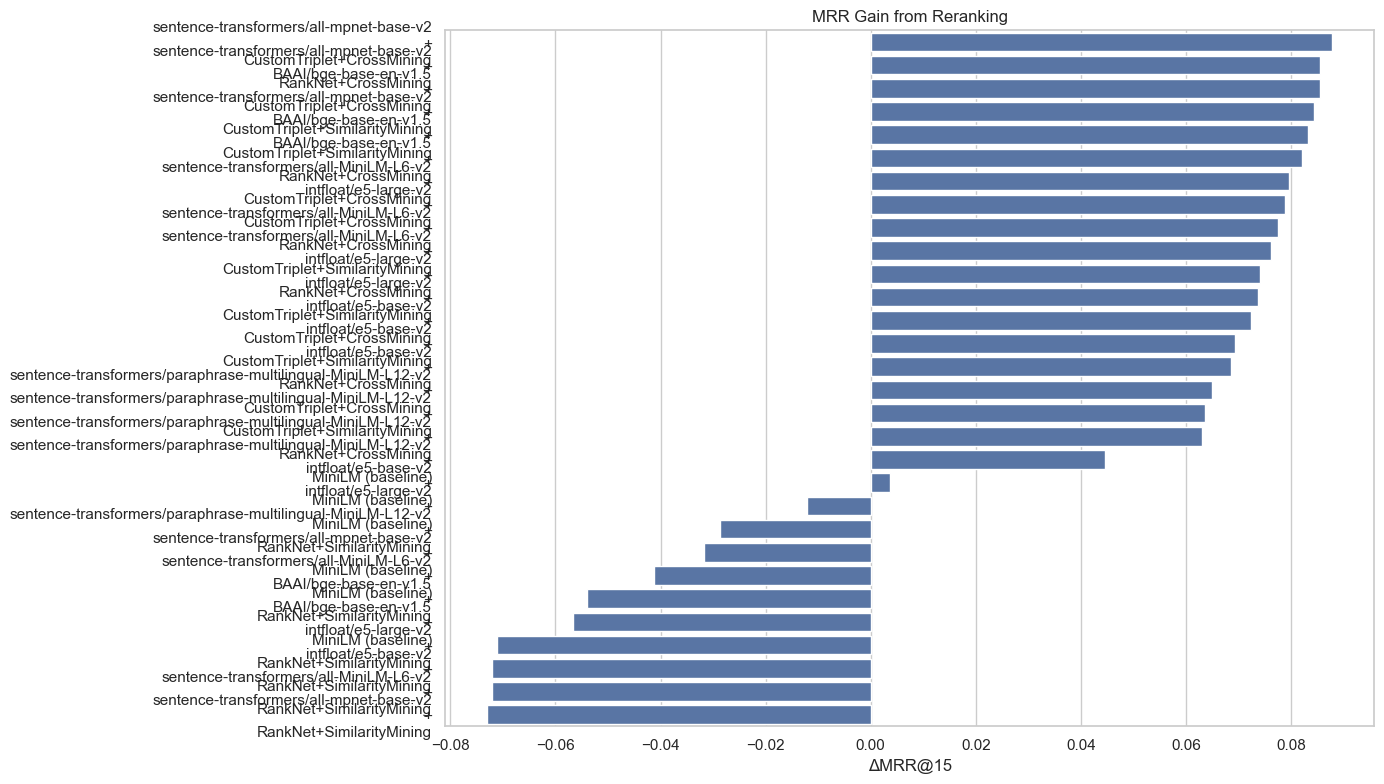

In [44]:
baseline = (
    df[df["reranker"] == "No_Reranker"]
    [["bi_encoder", "MRR@15"]]
    .rename(columns={"MRR@15": "baseline_mrr"})
)

gain_df = df.merge(
    baseline,
    on="bi_encoder",
    how="left"
)

gain_df["mrr_gain"] = (
    gain_df["MRR@15"]
    - gain_df["baseline_mrr"]
)

gain_df = gain_df[
    gain_df["reranker"] != "No_Reranker"
]

gain_df = gain_df.sort_values(
    "mrr_gain",
    ascending=False
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=gain_df,
    x="mrr_gain",
    y="config"
)

plt.title("MRR Gain from Reranking")
plt.xlabel("ΔMRR@15")
plt.ylabel("")
plt.tight_layout()

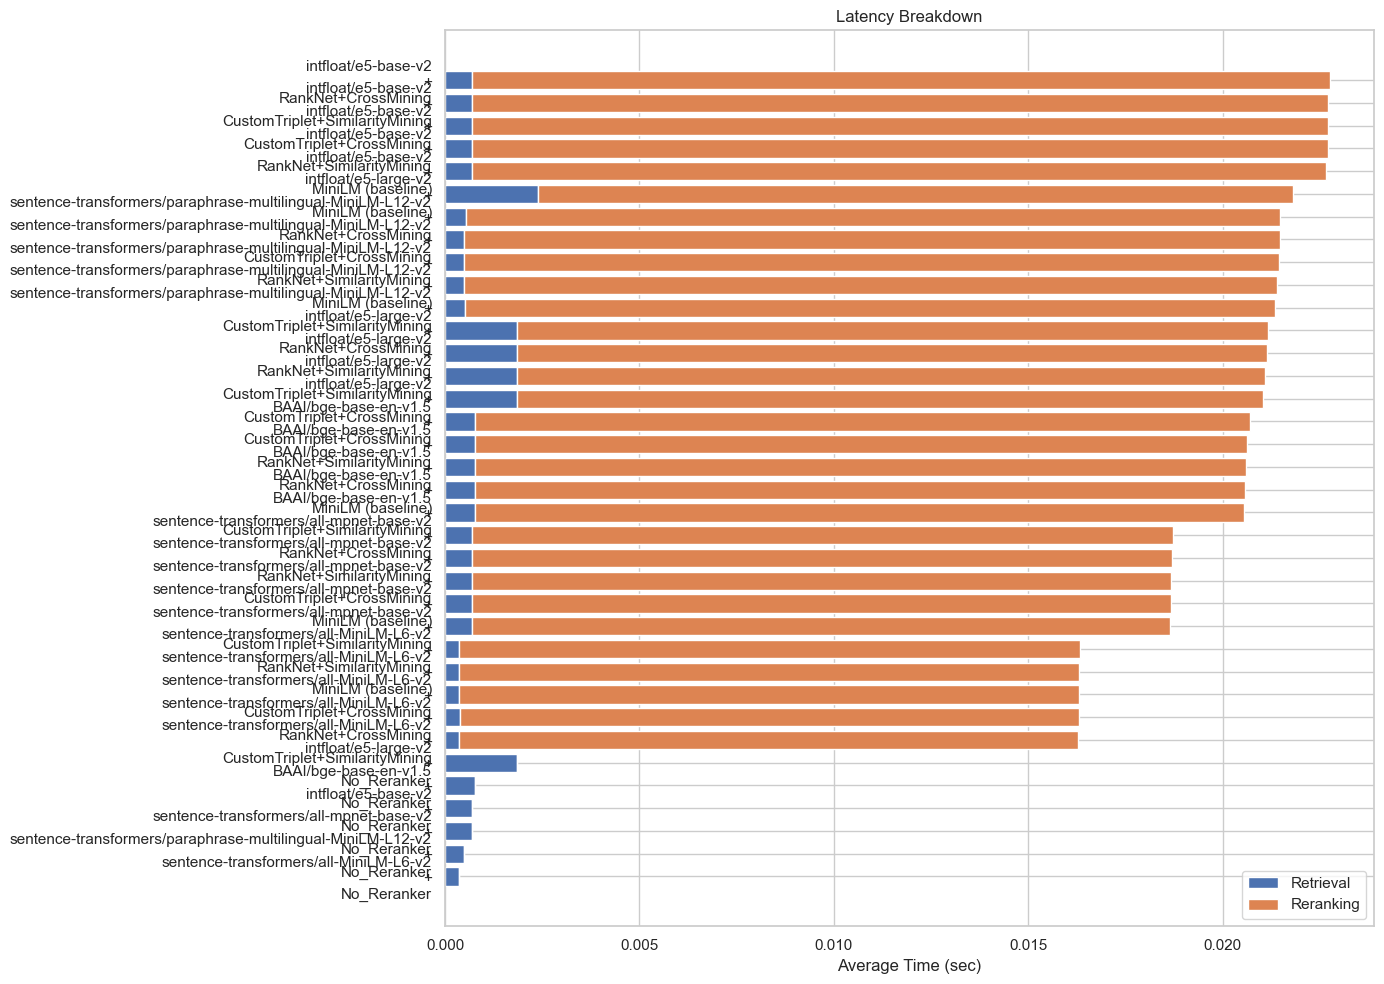

In [45]:
plot_df = (
    df.sort_values("total_latency")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 10))

ax.barh(
    plot_df["config"],
    plot_df["avg_time_retrieval_sec"],
    label="Retrieval"
)

ax.barh(
    plot_df["config"],
    plot_df["avg_time_rerank_sec"],
    left=plot_df["avg_time_retrieval_sec"],
    label="Reranking"
)

ax.set_xlabel("Average Time (sec)")
ax.set_title("Latency Breakdown")
ax.legend()

plt.tight_layout()